In [5]:
from scripts.circuit_frame import circuit_frame_evaluation
from circuit_generation import build_ansatz
import matplotlib.pyplot as plt
from numpy import arccos, pi
from frame_potential_gpu import compute_frame_potential_gpu
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector

from qiskit.converters import circuit_to_instruction
from circuit_generation import perfectSU4_anzatz


In [6]:
from math import asin, acos
import numpy as np

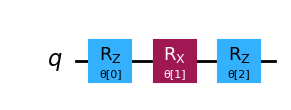

In [7]:
qc = QuantumCircuit(1)
params = ParameterVector('θ', 5)
qc.rz(params[0], 0)
qc.rx(params[1], 0)
qc.rz(params[2], 0)
qc.draw("mpl")

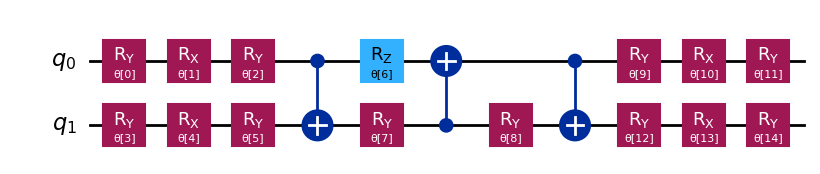

In [9]:
qc = perfectSU4_anzatz(n_qubits=2,reps=1, parameter_prefix="θ")
qc.draw("mpl")


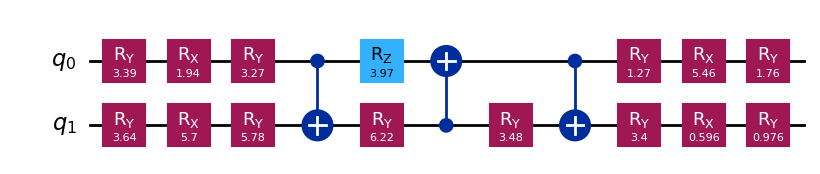

In [10]:
# bound the parameters of the circuit to randomely generated values

random_parameters = np.random.uniform(0, 2*pi, size=15)
qc_bound = qc.assign_parameters(random_parameters)
qc_bound.draw("mpl")

In [11]:
bit_indices = {
                bit: index
                for bits in [qc.qubits, qc.clbits]
                for index, bit in enumerate(bits)
            }
qargs = [bit_indices[tup] for tup in qc.qubits]
print(qargs, bit_indices)

[0, 1] {<Qubit register=(2, "q"), index=0>: 0, <Qubit register=(2, "q"), index=1>: 1}


In [ ]:
# build any circuit here

bit_indices = {
                bit: index
                for bits in [qc.qubits, qc.clbits]
                for index, bit in enumerate(bits)
            }
qargs = [bit_indices[tup] for tup in qc.qubits]

def compose(op, mat, qargs):
    ## to do
    pass

for instruction in qc_bound:
    print(instruction.qubits[0])
    mat = instruction.operation.to_matrix()
    #print(instruction.operation.name, mat)
    new_qargs = [qargs[bit_indices[tup]] for tup in instruction.qubits]


AttributeError: 'qiskit.circuit.Qubit' object has no attribute 'find_bit'

In [4]:
def parameter_composer(parameters):
    for i in range(len(parameters)):
        if i == 1:
            parameters[i] = acos(parameters[i]/pi - 1)
    return parameters

In [72]:
F_p = compute_frame_potential_gpu(qc, t=2, n_samples=1000,verbose=False)
F_p_composed = compute_frame_potential_gpu(qc, t=2, n_samples=10000, parameter_composer=parameter_composer, verbose=False)
F_p_3 = compute_frame_potential_gpu(qc, t=3, n_samples=3000, parameter_composer=parameter_composer, verbose=False)

F_p_4 = compute_frame_potential_gpu(qc, t=4, n_samples=4000, parameter_composer=parameter_composer, verbose=False)

F_p_5 = compute_frame_potential_gpu(qc, t=5, n_samples=5000, parameter_composer=parameter_composer, verbose=False)




/home/tardant/Bureau/Qiskit/architectures/Frame potential/frame_potential_gpu.py:227: RuntimeWarning: Device does not support fp64; accumulating in float32.
  warnings.warn(
/home/tardant/Bureau/Qiskit/architectures/Frame potential/frame_potential_gpu.py:292: UserWarning: d=4 < 2t=10: large-d approximation may be inaccurate.
  warnings.warn(f"d={d} < 2t={2*t}: large-d approximation may be inaccurate.")


In [73]:

print("Frame potential (without parameter composer):", F_p["frame_potential"])
print("Frame potential (with parameter composer):", F_p_composed["frame_potential"])
print("Frame potential (t=3 with parameter composer):", F_p_3["frame_potential"])                
print("Frame potential (t=4 with parameter composer):", F_p_4["frame_potential"])  
print("Frame potential (t=5 with parameter composer):", F_p_5["frame_potential"])


Frame potential (without parameter composer): 2.144197940826416
Frame potential (with parameter composer): 2.1448967456817627
Frame potential (t=3 with parameter composer): 7.2649149894714355
Frame potential (t=4 with parameter composer): 33.38103103637695
Frame potential (t=5 with parameter composer): 197.56187438964844


In [6]:
F_p_composed["fidelity_error"]

0.00031624592050929215

Composition liste for perfect_SU4 ansatz: []
number of parameters in SU4 anatz:       15
number of parameters in brickwall anatz: 16


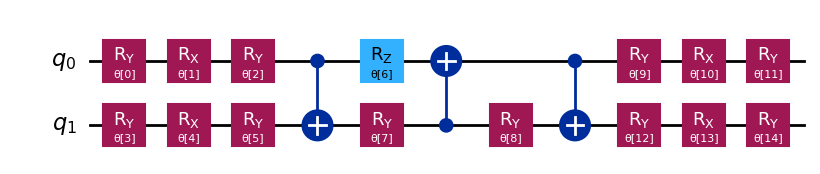

In [40]:
composer_liste = []
qc_su4 = build_ansatz(name="perfect_SU4", n_parameters=15, reps=0, parameter_prefix="θ", composition_liste=composer_liste)
qc_brick = build_ansatz(name="brickwall", n_qubits=2, reps=3, parameter_prefix="θ")
print("Composition liste for perfect_SU4 ansatz:", composer_liste)
print(f'number of parameters in SU4 anatz:       {len(qc_su4.parameters)}')
print(f'number of parameters in brickwall anatz: {len(qc_brick.parameters)}')
qc_su4.draw("mpl")

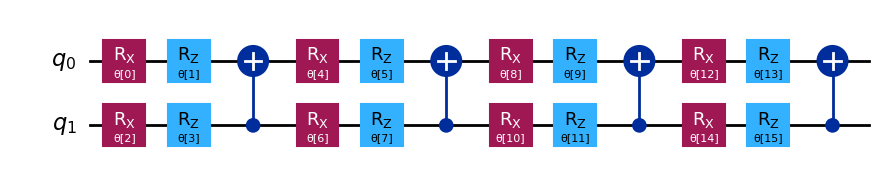

In [41]:
qc_brick.draw("mpl")

In [42]:
def parameter_composer_su4(theta):
    for t in range(len(theta)):
        if t in [1,4,10,13,6,7,8]:
            theta[t] = acos(theta[t]/np.pi-1)

def parameter_composer_brickwall(theta):
    for t in range(len(theta)):
        if t%2 == 0:
            theta[t] = acos(theta[t]/np.pi-1)

In [45]:

F_p = compute_frame_potential_gpu(qc_su4, t=2, n_samples=1000,verbose=False)
F_p_composed = compute_frame_potential_gpu(qc_su4, t=2, n_samples=4000, parameter_composer=parameter_composer_su4, verbose=False)
F_p_brick = compute_frame_potential_gpu(qc_brick, t=2, n_samples=1000, verbose=False)
F_p_composed_brick = compute_frame_potential_gpu(qc_brick, t=2, n_samples=1000, parameter_composer=parameter_composer_brickwall, verbose=False)

In [46]:


print(f"Frame potential (without parameter composer): {F_p['frame_potential']} \u00B1 {F_p['fidelity_error']}")
print(f"Frame potential (with parameter composer): {F_p_composed['frame_potential']} \u00B1 {F_p_composed['fidelity_error']}")
print(f"Frame potential for brickwall ansatz (without parameter composer): {F_p_brick['frame_potential']} \u00B1 {F_p_brick['fidelity_error']}")
print(f"Frame potential for brickwall ansatz (with parameter composer): {F_p_composed_brick['frame_potential']} \u00B1 {F_p_composed_brick['fidelity_error']}")


Frame potential (without parameter composer): 2.1548259258270264 ± 0.0054547335375523375
Frame potential (with parameter composer): 2.014526605606079 ± 0.001147320002565033
Frame potential for brickwall ansatz (without parameter composer): 2.0545384883880615 ± 0.00478884165318425
Frame potential for brickwall ansatz (with parameter composer): 2.065478563308716 ± 0.004848801470663065


In [98]:
from circuit_generation import perfectSU4_anzatz

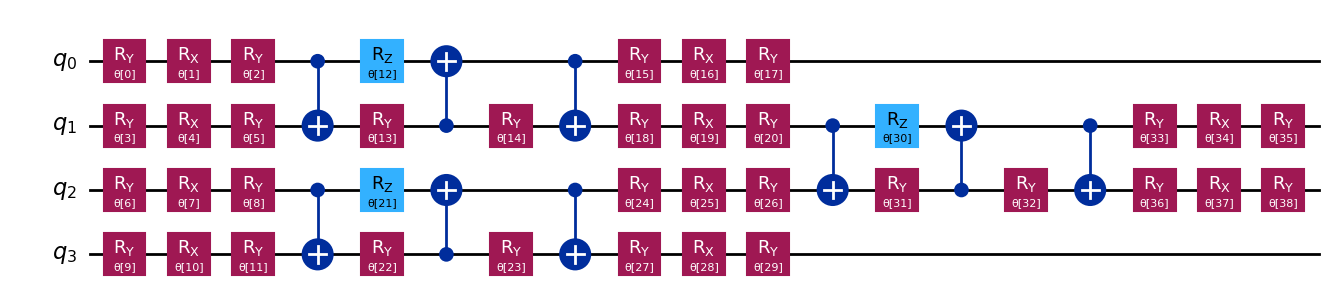

In [27]:
acos_list = []
qc_SU4_4qubits = perfectSU4_anzatz(n_qubits=4,reps=1, parameter_prefix="θ", acos_list=acos_list)
qc_brick = build_ansatz(name="brickwall", n_qubits=4, reps=2, parameter_prefix="θ", initial_rotation=False)
qc_brick_initial_rotation = build_ansatz(name="brickwall", n_qubits=4, reps=2, parameter_prefix="θ", initial_rotation=True)
qc_SU4_4qubits.draw("mpl")

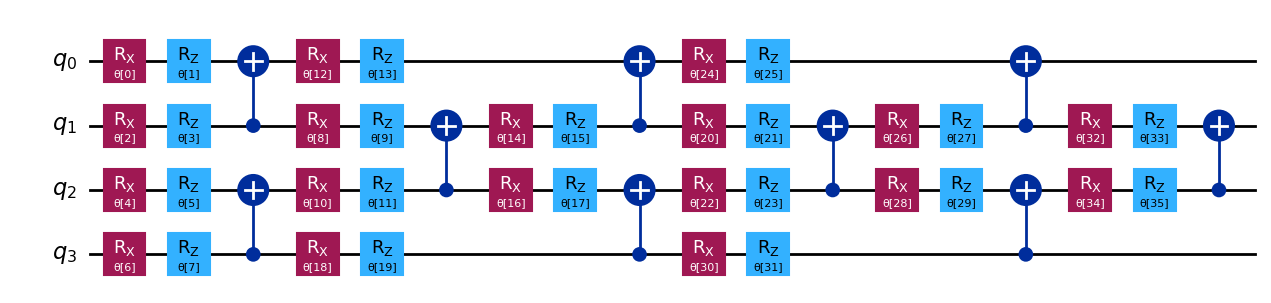

In [28]:
qc_brick.draw("mpl")

In [29]:
print(f'number of parameters in SU4 anatz:       {len(qc_SU4_4qubits.parameters)}')
print(f'number of parameters in brickwall anatz: {len(qc_brick.parameters)}')

number of parameters in SU4 anatz:       39
number of parameters in brickwall anatz: 36


In [30]:
def parameter_composer_8qubits(theta):
    for i in acos_list:
        theta[i] = acos(theta[i]/np.pi-1)

def parameter_composer_brickwall(theta):
    for i in range(len(theta)):
        if i%2 == 0:
            theta[i] = acos(theta[i]/np.pi-1)
        
def parameter_composer_brickwall_initial_rotation(theta):
    for i in range(len(theta)):
        if i%2 == 1:
            theta[i] = acos(theta[i]/np.pi-1)

In [31]:

F_p = compute_frame_potential_gpu(qc_SU4_4qubits, t=2, n_samples=1000,verbose=False)
F_p_composed = compute_frame_potential_gpu(qc_SU4_4qubits, t=2, n_samples=1000, parameter_composer=parameter_composer_8qubits, verbose=False)
F_p_brick = compute_frame_potential_gpu(qc_brick, t=2, n_samples=1000, verbose=False)
F_p_composed_brick = compute_frame_potential_gpu(qc_brick, t=2, n_samples=1000, parameter_composer=parameter_composer_brickwall, verbose=False)
F_p_initial_rotation = compute_frame_potential_gpu(qc_brick_initial_rotation, t=2, n_samples=1000, verbose=False)
F_p_composed_brick_initial_rotation = compute_frame_potential_gpu(qc_brick_initial_rotation, t=2, n_samples=1000, parameter_composer=parameter_composer_brickwall_initial_rotation, verbose=False)

/home/tardant/Bureau/Qiskit/architectures/Frame potential/frame_potential_gpu.py:227: RuntimeWarning: Device does not support fp64; accumulating in float32.
  warnings.warn(


In [32]:
print(f"Frame potential (without parameter composer): {F_p['frame_potential']} \u00B1 {F_p['fidelity_error']}")
print(f"Frame potential (with parameter composer): {F_p_composed['frame_potential']} \u00B1 {F_p_composed['fidelity_error']}")
print("------------------------------------------------")
print(f"Frame potential for brickwall ansatz (without parameter composer): {F_p_brick['frame_potential']} \u00B1 {F_p_brick['fidelity_error']}")
print(f"Frame potential for brickwall ansatz (with parameter composer): {F_p_composed_brick['frame_potential']} \u00B1 {F_p_composed_brick['fidelity_error']}")
print("------------------------------------------------")
print(f"Frame potential for brickwall ansatz with initial rotation (without parameter composer): {F_p_initial_rotation['frame_potential']} \u00B1 {F_p_initial_rotation['fidelity_error']}")
print(f"Frame potential for brickwall ansatz with initial rotation (with parameter composer): {F_p_composed_brick_initial_rotation['frame_potential']} \u00B1 {F_p_composed_brick_initial_rotation['fidelity_error']}")

Frame potential (without parameter composer): 3.06550931930542 ± 0.014634866630381792
Frame potential (with parameter composer): 2.67844557762146 ± 0.01057749569709995
------------------------------------------------
Frame potential for brickwall ansatz (without parameter composer): 2.2764053344726562 ± 0.006852285697116134
Frame potential for brickwall ansatz (with parameter composer): 2.276524066925049 ± 0.006935306236585004
------------------------------------------------
Frame potential for brickwall ansatz with initial rotation (without parameter composer): 2.2280187606811523 ± 0.006415312520930756
Frame potential for brickwall ansatz with initial rotation (with parameter composer): 2.224958896636963 ± 0.00650421739355227


In [51]:
from qiskit.quantum_info import Operator


In [71]:
qc = build_ansatz(name="perfect_SU4", n_parameters=15, reps=0, parameter_prefix="θ", composition_liste=composer_liste)
# transform qc into it matric representation
tests = 10
paremeters_indexes = [6,7,8]
count_swap = 0
count_invert = 0
for _ in range(tests) :
    # sample raondom parameters for the circuit
    random_parameters = np.random.uniform(0, 2*np.pi, len(qc.parameters))
    # bind the parameters to the circuit
    params = qc.parameters
    bound  = qc.assign_parameters(dict(zip(params, random_parameters)))
    Operator(bound).data
    for s in range(3):
        # swap the parameters at the indexes 7,8,9 among themselves
        random_parameters[paremeters_indexes] = np.random.permutation(random_parameters[paremeters_indexes])
        # bind the new parameters to the circuit
        bound_swap  = qc.assign_parameters(dict(zip(params, random_parameters)))
        # check that the unitary of the circuit is the same as before
        compar = np.allclose(Operator(bound).data, Operator(bound_swap).data, atol=1e-6)
        if compar:
            count_swap += 1
    
    # sample raondom parameters for the circuit
    random_parameters = np.random.uniform(0, 2*np.pi, len(qc.parameters))
    # bind the parameters to the circuit
    params = qc.parameters
    bound  = qc.assign_parameters(dict(zip(params, random_parameters)))
    Operator(bound).data
    
    for s in range(3):
        # multiply by -1 one of the parameters at the indexes 7,8,9
        random_parameters[paremeters_indexes[s]] *= -1
        # bind the new parameters to the circuit
        bound_invert  = qc.assign_parameters(dict(zip(params, random_parameters)))
        # check that the unitary of the circuit is the same as before
        compar_invert = np.allclose(Operator(bound).data, Operator(bound_invert).data, atol=1e-6)
        if compar_invert:
            count_invert += 1
        random_parameters[paremeters_indexes[s]] *= -1 # revert the change for the next iteration
print(f"Swap Test passed {count_swap} times out of {tests*3} with parameters at indexes {paremeters_indexes}")
print(f"Invert Test passed {count_invert} times out of {tests*3} with parameters at indexes {paremeters_indexes}")


Swap Test passed 5 times out of 30 with parameters at indexes [6, 7, 8]
Invert Test passed 0 times out of 30 with parameters at indexes [6, 7, 8]


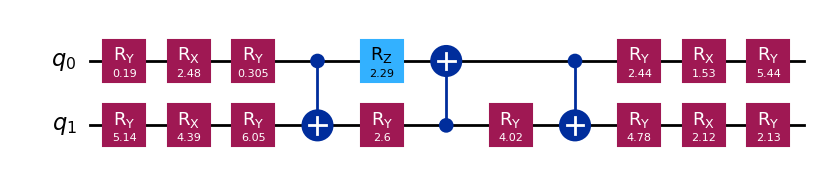

In [61]:
bound.draw("mpl")

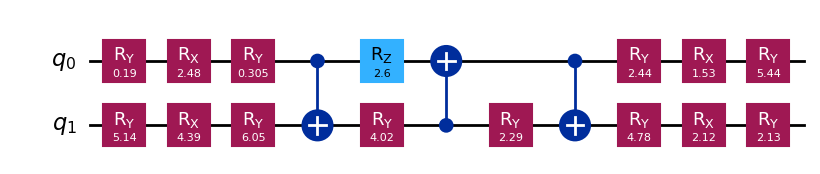

In [62]:
bound_swap.draw("mpl")

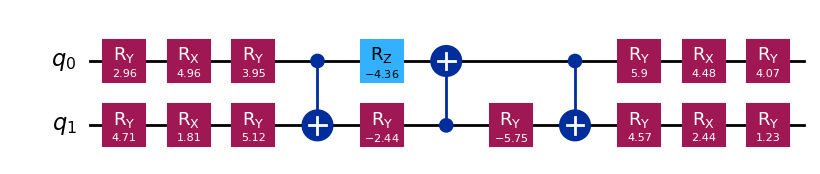

In [69]:
bound_invert.draw("mpl")